# Sentiment Analysis Model

In [ ]:
# Mount drive

from google.colab import drive
drive.mount('/content/drive')

path = '/content/drive/MyDrive/nlp_final_project/'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# load data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# df = pd.read_parquet('https://storage.googleapis.com/msca-bdp-data-open/news_final_project/news_final_project.parquet', engine='pyarrow')
# df.shape

In [ ]:
# raw data to drive
# df.to_parquet(path + 'raw_articles.parquet', index=False)

In [ ]:
df = pd.read_parquet(path + 'raw_articles.parquet', engine='pyarrow')
df.shape

(199989, 5)

In [ ]:
# column names
df.columns.tolist()

['url', 'date', 'language', 'title', 'text']

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 199989 entries, 0 to 199988
Data columns (total 5 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   url       199989 non-null  object
 1   date      199989 non-null  object
 2   language  199989 non-null  object
 3   title     199989 non-null  object
 4   text      199989 non-null  object
dtypes: object(5)
memory usage: 7.6+ MB


In [ ]:
with pd.option_context('display.max_colwidth', 200):
  display(df.head())

,url,date,language,title,text
0,https://blockworks.co/price/bad,2025-06-23,en,"Bad Idea AI Price (BAD), Market Cap, Price Today & Chart History - Blockworks","Bad Idea AI Price (BAD), Market Cap, Price Today & Chart History - BlockworksOpen menuBrandsnewsletterspodcastseventsroundtablestoken transparencyetf trackerpricesresearchanalyticshomepricesBad Id..."
1,https://boingboing.net/2024/07/01/this-ai-video-of-gymnastics-might-be-the-freakiest-ive-seen-yet.html,2024-07-01,en,This AI video of gymnastics might be the freakiest I've seen yet - Boing Boing,\n\nThis AI video of gymnastics might be the freakiest I've seen yet - Boing Boing\n\n \n\t\t\t\t\tMENU \n\n\t\t\t\t\t\tSEARCH \n\n\t\t\t\t\t\tSTORE ...
2,https://boingboing.net/2024/09/18/if-using-ai-feels-like-a-chore-try-this.html,2024-09-22,en,"If using AI feels like a chore, try this - Boing Boing","\n\nIf using AI feels like a chore, try this - Boing Boing\n \n\t\t\t\t\tMENU \n\n\t\t\t\t\t\tSEARCH \n\n\t\t\t\t\t\tSTORE \n\n\n\t\t\t\t\t\t\t..."
3,https://citylife.capetown/gl/uncategorized/the-road-ahead-how-chinas-ai-foundation-model-is-shaping-the-future-of-autonomous-driving-technology/427293/,2023-11-10,en,The Road Ahead: How China's AI Foundation Model is Shaping the Future of Autonomous Driving Technology,The Road Ahead: How China's AI Foundation Model is Shaping the Future of Autonomous Driving Technology \n \n\nIr ao contidoVen. 10 de novembro de 2023 Vida da cidadePresentando...
4,https://citylife.capetown/kk/uncategorized/microsoft-and-nvidia-are-making-it-easier-to-run-ai-models-on-windows/451379/,2023-11-19,en,Microsoft and Nvidia to Empower Developers with Windows AI Studio,"Microsoft and Nvidia to Empower Developers with Windows AI Studio \n \n\nмазмұнға өтуСенбі. 18 қараша, 2023 жыл Қала өміріЖаңа технологиялар мен AI күшін ашу\n \n\nAIжаңалықта..."


In [ ]:
# check nulls
df.isnull().sum()

,0
url,0
date,0
language,0
title,0
text,0


In [ ]:
# check duplicates
df['text'].duplicated().sum()

np.int64(494)

In [ ]:
duplicated_text = df[df['text'].duplicated(keep=False)]
duplicated_text.sort_values(by='text').head(10)

,url,date,language,title,text
112288,https://www.cloudflare.com/en-gb/press-releases/2025/cloudflare-works-with-the-leading-ai-companies-to-strengthen-generative-ai/,2025-08-26,en,Cloudflare Works with the Leading AI Companies to Strengthen Generative AI Security for Businesses | Cloudflare,\n\n\n \n Cloudflare Works with the Leading AI Companies to Strengthen Generative AI Security for Businesses | Cloudflare\n \n\n SupportLanguagesEnglishEnglish (United Kingdom)DeutschEspañol (...
31327,https://www.cloudflare.com/en-in/press-releases/2025/cloudflare-works-with-the-leading-ai-companies-to-strengthen-generative-ai/,2025-08-27,en,Cloudflare Works with the Leading AI Companies to Strengthen Generative AI Security for Businesses | Cloudflare,\n\n\n \n Cloudflare Works with the Leading AI Companies to Strengthen Generative AI Security for Businesses | Cloudflare\n \n\n SupportLanguagesEnglishEnglish (United Kingdom)DeutschEspañol (...
170604,https://www.cloudflare.com/en-ca/press-releases/2025/cloudflare-works-with-the-leading-ai-companies-to-strengthen-generative-ai/,2025-08-26,en,Cloudflare Works with the Leading AI Companies to Strengthen Generative AI Security for Businesses | Cloudflare,\n\n\n \n Cloudflare Works with the Leading AI Companies to Strengthen Generative AI Security for Businesses | Cloudflare\n \n\n SupportLanguagesEnglishEnglish (United Kingdom)DeutschEspañol (...
148369,https://www.cloudflare.com/en-au/press-releases/2025/cloudflare-works-with-the-leading-ai-companies-to-strengthen-generative-ai/,2025-08-26,en,Cloudflare Works with the Leading AI Companies to Strengthen Generative AI Security for Businesses | Cloudflare,\n\n\n \n Cloudflare Works with the Leading AI Companies to Strengthen Generative AI Security for Businesses | Cloudflare\n \n\n SupportLanguagesEnglishEnglish (United Kingdom)DeutschEspañol (...
141795,https://www.cloudflare.com/press-releases/2024/cloudflare-enhances-ai-inference-platform-with-powerful-gpu-upgrade/,2024-10-16,en,"Cloudflare Enhances AI Inference Platform with Powerful GPU Upgrade, Faster Inference, Larger Models, Observability, and Upgraded Vector Database | Cloudflare","\n\n\n Cloudflare Enhances AI Inference Platform with Powerful GPU Upgrade, Faster Inference, Larger Models, Observability, and Upgraded Vector Database | Cloudflare\n \n Cloudflare Enhances A..."
28106,https://www.cloudflare.com/en-gb/press-releases/2024/cloudflare-enhances-ai-inference-platform-with-powerful-gpu-upgrade/,2024-10-16,en,"Cloudflare Enhances AI Inference Platform with Powerful GPU Upgrade, Faster Inference, Larger Models, Observability, and Upgraded Vector Database | Cloudflare","\n\n\n Cloudflare Enhances AI Inference Platform with Powerful GPU Upgrade, Faster Inference, Larger Models, Observability, and Upgraded Vector Database | Cloudflare\n \n Cloudflare Enhances A..."
100251,https://www.cloudflare.com/press-releases/2024/cloudflare-helps-content-creators-regain-control-of-content-from-ai/,2024-10-16,en,Cloudflare Helps Content Creators Regain Control of their Content from AI Bots | Cloudflare,\n\n\n Cloudflare Helps Content Creators Regain Control of their Content from AI Bots | Cloudflare\n \n Cloudflare Helps Content Creators Regain Control of their Content from AI BotsWith new t...
164919,https://www.cloudflare.com/en-gb/press-releases/2024/cloudflare-helps-content-creators-regain-control-of-content-from-ai/,2024-10-16,en,Cloudflare Helps Content Creators Regain Control of their Content from AI Bots | Cloudflare,\n\n\n Cloudflare Helps Content Creators Regain Control of their Content from AI Bots | Cloudflare\n \n Cloudflare Helps Content Creators Regain Control of their Content from AI BotsWith new t...
104152,https://www.lg.com/ca_en/tv-soundbars/4k-uhd-tvs/75un7370pub1/,2023-12-04,en,"75"" UN73 LG UHD TV with ThinQ® AI - 75UN7370PUB | LG CA","\n\n\n75"" UN73 LG UHD TV with ThinQ® AI - 75UN7370PUB | LG CA \n\nJavaScript appears to be disabled in your browser. Please enable JavaScript

In [ ]:
# drop dulicated text
df = df.drop_duplicates(subset='text', keep='first')
df.describe().T

,count,unique,top,freq
url,199495,199495,https://wysu.org/npr-national-news/2025-10-01/could-the-next-scarlett-johansson-or-natalie-portman-be-an-ai-avatar,1
date,199495,1499,2024-03-01,1559
language,199495,1,en,199495
title,199495,164305,Virtus Artificial Intelligence &amp; Technology Opportunities Fund Discloses Sources of Distribution - Section 19(a) Notice,65
text,199495,199495,\nCould 'the next Scarlett Johansson or Natalie Portman' be an AI avatar?\nSearch Query\nShow Search\n\nDonate a Vehicle to WYSU\nHome\n\nListen\n\nSupport\nNeed to Know News Fund\n\nDonate Now\n\...,1


In [ ]:
# article length distribution
text_len = df['text'].str.len()
text_len.describe()

,text
count,199495.000000
mean,9100.670583
std,7265.998323
min,21.000000
25%,5246.000000
50%,7621.000000
75%,11388.000000
max,580772.000000


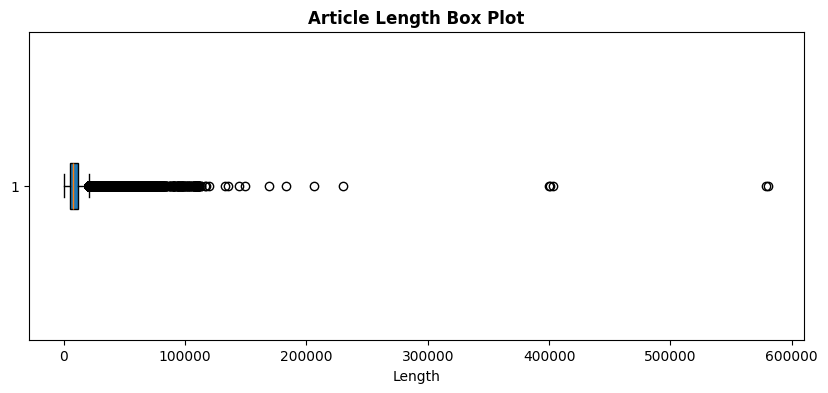

In [ ]:
plt.figure(figsize=(10, 4))
plt.boxplot(text_len, vert=False, patch_artist=True)
plt.title('Article Length Box Plot',fontweight = 'bold')
plt.xlabel('Length')
plt.show()

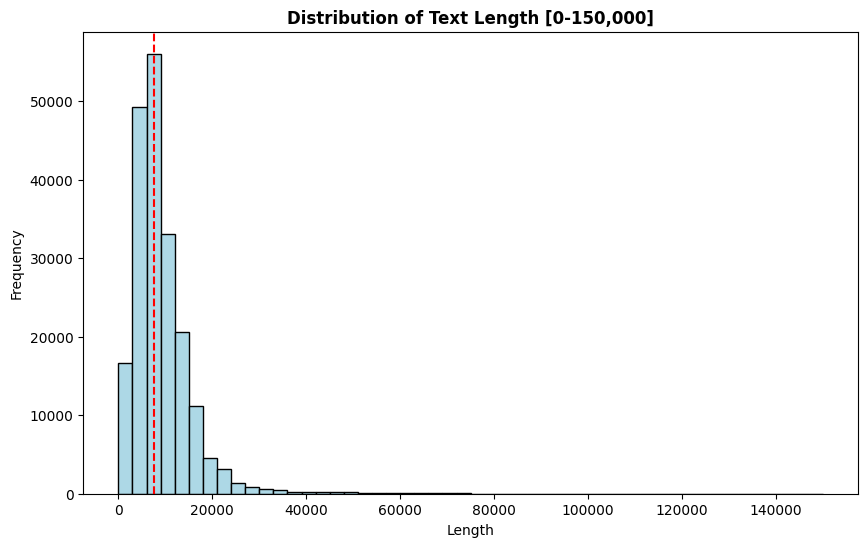

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 6))
plt.hist(df['text'].str.len(),bins=50,range=(0,150000),color='lightblue', edgecolor = 'black')
plt.title('Distribution of Text Length [0-150,000]',fontweight = 'bold')

# Adding a median line for context
median_len = np.median(df['text'].str.len())
plt.axvline(median_len, color='red', linestyle='--', label=f'Median: {median_len:.0f}')

plt.xlabel('Length')
plt.ylabel('Frequency')
plt.show()

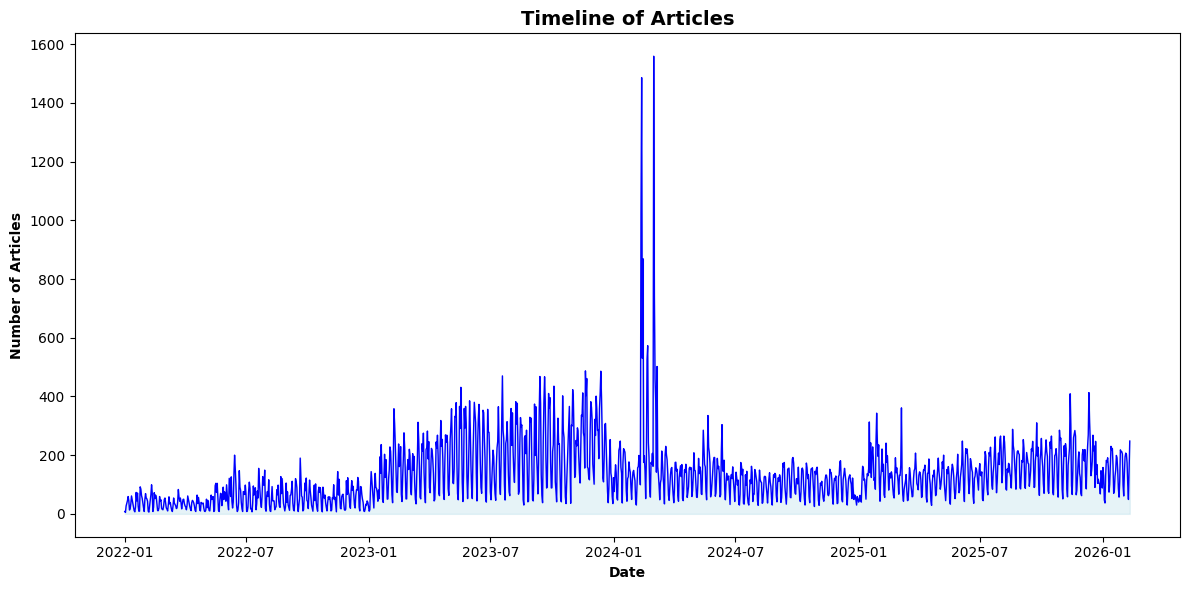

In [ ]:
df['date'] = pd.to_datetime(df['date'])

# articles per day
timeline = df['date'].dt.date.value_counts().sort_index()

plt.figure(figsize=(12, 6))
plt.plot(timeline.index, timeline.values, color='blue', linewidth=1)
plt.fill_between(timeline.index, timeline.values, alpha=0.3, color='lightblue')

plt.title('Timeline of Articles', fontsize=14, fontweight='bold')
plt.xlabel('Date',fontweight='bold')
plt.ylabel('Number of Articles',fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# pd.set_option('display.max_colwidth', None)
# df.sample(25)[['title', 'text']].values

In [ ]:
near_duplicates = df[df.duplicated(subset='title', keep=False)].sort_values(by='title')
print(near_duplicates.shape)

(42964, 5)


In [ ]:
pd.set_option('display.max_colwidth', 200)
near_duplicates[['title', 'text']].sample(10)

,title,text
162162,The third Wireless Communication AI Competition has been launched by IMT-2020(5G) Promotion Group,The third Wireless Communication AI Competition has been launched by IMT-2020(5G) Promotion Group\n\nSkip to contentNewsWeatherLatest VideoLIVESportsHomeNewsLocalRegionalNationalInternationalPolit...
150794,Gay couple love. AI generated | Premium Photo - rawpixel,Gay couple love. AI generated | Premium Photo - rawpixelrawpixelElementsDesignsDesign topicsElement topicsBoardshttps://www.rawpixel.com/services/licenseshttps://www.rawpixel.com/image/12630936Ed...
110163,Hackers aim to find flaws in AI - with White House help,\nHackers aim to find flaws in AI - with White House help\n\n \n\n \n \n\n \n\n \n\n \n\n \n\n \n\n \nSkip to main content\nTurn off refresh\n\n\n \n\nCurrently Reading\nHackers aim to find flaws ...
37757,Study Finds that AI Model Can Help Optimize Ovulation Trigger Injection Timing to Improve Outcomes for IVF Patients,Study Finds that AI Model Can Help Optimize Ovulation Trigger Injection Timing to Improve Outcomes for IVF Patients\n\nSkip to contentGetting AnswersA Slice of Nice ContestYokem ConnectionAdvertis...
63196,ESG and AI Take Center Stage at TraceGains' 2023 Customer Executive Advisory Board Summit,ESG and AI Take Center Stage at TraceGains' 2023 Customer Executive Advisory Board Summit\n\nSkip to contentCommunity Coverage TourHome ProMedically SpeakingBest of the WestChampions in AgBack to ...
177559,Global study shows Artificial Intelligence can reduce time to pregnancy for IVF couples by 12%,\n\n \nGlobal study shows Artificial Intelligence can reduce time to pregnancy for IVF couples by 12%\n\n \nResources\n\n\nBlog\n\n\nJournalists\n\n\nWebcasts\n \nData Privacy\n\n\n \nFrançais\n\n...
30110,EdgeCortix Expands Delivery of its Industry Leading SAKURA-I AI Co-processor Devices and MERA Software Suite,EdgeCortix Expands Delivery of its Industry Leading SAKURA-I AI Co-processor Devices and MERA Software Suite\n\nSkip to contentFirst Alert WeatherNBC15 InvestigatesLatest NewsNewscastsConnectedHom...
22316,TEMPUS AI SHAREHOLDER ALERT: CLAIMSFILER REMINDS INVESTORS,"\n\nTEMPUS AI SHAREHOLDER ALERT: CLAIMSFILER REMINDS INVESTORS\n\nAccessibility: Skip TopNav\nTEMPUS AI SHAREHOLDER ALERT: CLAIMSFILER REMINDS INVESTORS WITH LOSSES IN EXCESS OF $100,000 of Lead P..."
164591,QorusDocs Appoints Jon Roskill to its Board to Support Meteoric Rise in Demand for Generative AI Proposal Management Software,QorusDocs Appoints Jon Roskill to its Board to Support Meteoric Rise in Demand for Generative AI Proposal Management Software\n\nSkip to contentTexoma LocalExpert AdviceJobs In TexomaAdvertise Wit...
166579,Ordaōs Selected to Participate in the AWS Generative AI Accelerator,Ordaōs Selected to Participate in the AWS Generative AI Accelerator\n\nSkip to contentWe are LocalOmaha EverydayAdvertise With UsHeartland HeroesFirst Alert Weather24/7 WeatherLivestream6 News Str...


In [ ]:
# clean null columns
df = df[df['text'].notna()]
df = df[df['text'].str.strip() != '']
df.shape

(199495, 5)

In [ ]:
# drop extremely short articles
min_chars = 200
df = df[df['text'].str.len() >= min_chars]
df.shape

(198610, 5)

In [ ]:
df.shape

(198610, 5)

In [ ]:
!pip install langdetect

In [ ]:
!pip install pycld2

In [ ]:
import pycld2 as cld2

def get_language_fast(text):
    try:
        if not isinstance(text, str) or len(text.strip()) == 0:
            return 'unknown'


        _, _, details = cld2.detect(text)
        return details[0][1]
    except Exception:
        return 'unknown'

df['language'] = df['text'].apply(get_language_fast)

In [ ]:
df['language'].value_counts()

,count
language,
en,197850
unknown,562
haw,30
un,18
tr,16
it,15
sm,15
ru,14
ha,10


In [ ]:
# preview of other languages
# df[df['language'] == 'ny'].sample(10)[['title', 'text_clean','language']]

In [ ]:
df = df[df['language'].isin(['en', 'unknown'])]
df.shape

(198412, 5)

In [ ]:
# filter for topic relevant articles

relevance_words = [
     'artificial intelligence', 'machine learning', 'deep learning',
     'neural network', 'natural language processing', 'nlp',
     'large language model', 'llm', 'gpt', 'automation', 'algorithm',
     'data science', 'computer vision', 'robotics', 'ai ', ' ai,', ' ai.',
     'computer','technology','tech','claude','gemini'
 ]

def is_relevant(text):
  text_lower = text.lower()
  return any(kw in text_lower for kw in relevance_words)

df['is_relevant'] = df['text'].apply(is_relevant)
df['is_relevant'].value_counts()


/tmp/ipykernel_6633/3949120884.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['is_relevant'] = df['text'].apply(is_relevant)


,count
is_relevant,
True,196629
False,1783


In [ ]:
# preview articles with is_relevant = False
# df[~df['is_relevant']].sample(10)[['title', 'text_clean','is_relevant']]

In [ ]:
# drop articles with no relevant words, probably noise
df = df[df['is_relevant']].drop(columns=['is_relevant'])
df.shape

(196629, 5)

In [ ]:
import regex as re
from bs4 import BeautifulSoup

# unseen UI artifacts
combined_pattern = re.compile(r"""
    (?i)we\ use\ cookies.*?\.
    | subscribe\ (to|now).*?\.
    | \b(privacy\ policy|terms\ of\ (service|use)|cookie\ policy|all\ rights\ reserved)\b
    | (?:https?://)?(?:www\.)?[\w-]+\.[\w./?=#%&-]+
    | [\w\.-]+@[\w\.-]+\.\w+
    | ([A-Z][a-z]+(\s*[|>•/]\s*[A-Z][a-z]+){1,})
""", re.VERBOSE | re.IGNORECASE)

def data_cleaner_fast(text):
    if not isinstance(text, str) or not text.strip():
        return ""
    soup = BeautifulSoup(text, "lxml")

    for tag in soup(['nav', 'footer', 'script', 'style', 'header']):
        tag.decompose()

    text = soup.get_text(separator=" ")
    text = combined_pattern.sub(' ', text)
    text = re.sub(r'([>\-\|•]){2,}', ' ', text)
    return " ".join(text.split())

df['text_clean'] = df['text'].apply(data_cleaner_fast)

with pd.option_context('display.max_colwidth', 200):
  display(df.head())

,url,date,language,title,text,text_clean
0,https://blockworks.co/price/bad,2025-06-23,en,"Bad Idea AI Price (BAD), Market Cap, Price Today & Chart History - Blockworks","Bad Idea AI Price (BAD), Market Cap, Price Today & Chart History - BlockworksOpen menuBrandsnewsletterspodcastseventsroundtablestoken transparencyetf trackerpricesresearchanalyticshomepricesBad Id...","Bad Idea AI Price (BAD), Market Cap, Price Today & Chart History - BlockworksOpen menuBrandsnewsletterspodcastseventsroundtablestoken transparencyetf trackerpricesresearchanalyticshomepricesBad Id..."
1,https://boingboing.net/2024/07/01/this-ai-video-of-gymnastics-might-be-the-freakiest-ive-seen-yet.html,2024-07-01,en,This AI video of gymnastics might be the freakiest I've seen yet - Boing Boing,\n\nThis AI video of gymnastics might be the freakiest I've seen yet - Boing Boing\n\n \n\t\t\t\t\tMENU \n\n\t\t\t\t\t\tSEARCH \n\n\t\t\t\t\t\tSTORE ...,This AI video of gymnastics might be the freakiest I've seen yet - Boing Boing MENU SEARCH STORE MENU SEARCH STORE Blog : The posts Forums : Read the rules Store : Wonderful Products (Contact Supp...
2,https://boingboing.net/2024/09/18/if-using-ai-feels-like-a-chore-try-this.html,2024-09-22,en,"If using AI feels like a chore, try this - Boing Boing","\n\nIf using AI feels like a chore, try this - Boing Boing\n \n\t\t\t\t\tMENU \n\n\t\t\t\t\t\tSEARCH \n\n\t\t\t\t\t\tSTORE \n\n\n\t\t\t\t\t\t\t...","If using AI feels like a chore, try this - Boing Boing MENU SEARCH STORE MENU SEARCH STORE Blog : The posts Forums : Read the rules Store : Wonderful Products (Contact Support) Newsletter : Daily ..."
3,https://citylife.capetown/gl/uncategorized/the-road-ahead-how-chinas-ai-foundation-model-is-shaping-the-future-of-autonomous-driving-technology/427293/,2023-11-10,en,The Road Ahead: How China's AI Foundation Model is Shaping the Future of Autonomous Driving Technology,The Road Ahead: How China's AI Foundation Model is Shaping the Future of Autonomous Driving Technology \n \n\nIr ao contidoVen. 10 de novembro de 2023 Vida da cidadePresentando...,The Road Ahead: How China's AI Foundation Model is Shaping the Future of Autonomous Driving Technology Ir ao contidoVen. 10 de novembro de 2023 Vida da cidadePresentando as novas tecnoloxías e o p...
4,https://citylife.capetown/kk/uncategorized/microsoft-and-nvidia-are-making-it-easier-to-run-ai-models-on-windows/451379/,2023-11-19,en,Microsoft and Nvidia to Empower Developers with Windows AI Studio,"Microsoft and Nvidia to Empower Developers with Windows AI Studio \n \n\nмазмұнға өтуСенбі. 18 қараша, 2023 жыл Қала өміріЖаңа технологиялар мен AI күшін ашу\n \n\nAIжаңалықта...","Microsoft and Nvidia to Empower Developers with Windows AI Studio мазмұнға өтуСенбі. 18 қараша, 2023 жыл Қала өміріЖаңа технологиялар мен AI күшін ашу AIжаңалықтарғарыштехнологиясерікғылымАҚШбайла..."


In [ ]:
# parse dates
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['date'].isna().sum()

# year, month, year_month for analysis
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['year_month'] = df['date'].dt.to_period('M')

In [ ]:
df.describe(include='all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
url,196629,196629,https://wysu.org/npr-national-news/2025-10-01/could-the-next-scarlett-johansson-or-natalie-portman-be-an-ai-avatar,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date,196629,NaN,NaN,NaN,2024-04-14 04:22:28.317897984,2022-01-01 00:00:00,2023-07-04 00:00:00,2024-02-17 00:00:00,2025-03-19 00:00:00,2026-02-10 00:00:00,NaN
language,196629,2,en,196068,NaN,NaN,NaN,NaN,NaN,NaN,NaN
title,196629,161744,Virtus Artificial Intelligence &amp; Technology Opportunities Fund Discloses Sources of Distribution - Section 19(a) Notice,65,NaN,NaN,NaN,NaN,NaN,NaN,NaN
text,196629,196629,\nCould 'the next Scarlett Johansson or Natalie Portman' be an AI avatar?\nSearch Query\nShow Search\n\nDonate a Vehicle to WYSU\nHome\n\nListen\n\nSupport\nNeed to Know News Fund\n\nDonate Now\n\...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
text_clean,196629,196594,Don’t expect quick fixes in ‘red-teaming’ of AI models. Security was an Seattle Times Skip to content Coronavirus Local News Traffic Lab Law & Justice Local Politics Education Education Lab Eastsi...,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year,196629.0,NaN,NaN,NaN,2023.787885,2022.0,2023.0,2024.0,2025.0,2026.0,1.033383
month,196629.0,NaN,NaN,NaN,6.5022,1.0,3.0,7.0,10.0,12.0,3.507801
year_month,196629,50,2024-02,8181,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df[['text_clean', 'date', 'title']].isnull().sum()

,0
text_clean,0
date,0
title,0


In [ ]:
df['text_clean'].str.len().describe()

,text_clean
count,196629.000000
mean,8176.046911
std,6173.040604
min,145.000000
25%,4809.000000
50%,6947.000000
75%,10167.000000
max,339722.000000


<Axes: xlabel='year_month'>

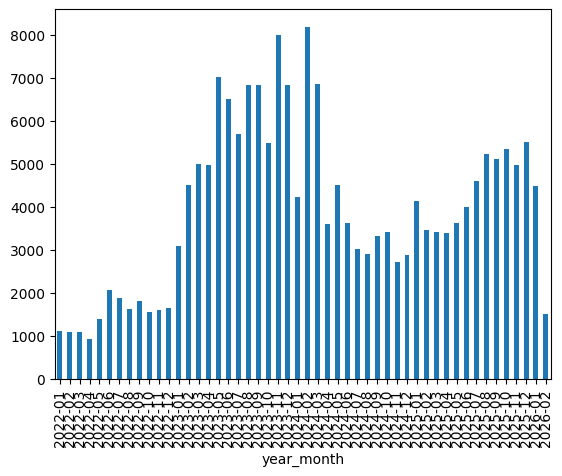

In [ ]:
df['year_month'].value_counts().sort_index().plot(kind='bar')

In [ ]:

def remove_surrogates(text):
    if not isinstance(text, str):
        return text
    return text.encode('utf-8', errors='ignore').decode('utf-8')


final_columns = ['title', 'text_clean', 'year', 'date', 'year_month']
df_final = df[final_columns].reset_index(drop=True)


df_final['article_id'] = df_final.index


df_final['text_clean'] = df_final['text_clean'].apply(remove_surrogates)
df_final['title'] = df_final['title'].apply(remove_surrogates)


df_final.to_parquet(path + 'cleaned_articles.parquet', index=False)

In [ ]:
print(f"Saved {df_final.shape[0]} cleaned articles to parquet.")

Saved 196629 cleaned articles to parquet.
